# 2.2 $\quad$ Análisis del efecto de la diversificación en el riesgo de una cartera

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


plt.style.use("ggplot")

## 1. Efecto de la diversificación en el riesgo de una cartera

Hemos visto que la varianza de una cartera de dos activos viene definida por:

$$\sigma^2_p= \underset{\text{Activo 1}} {\underbrace{w_1^2\sigma^2_1}}+\underset{\text{Activo 2}} {\underbrace{w_2^2\sigma^2_2}}+ \underset{\text{Relación entre activos}} {\underbrace{2w_1w_2 \sigma_{12}}}$$
       


Podemos generalizar para una cartera con $n$ activos:

$$\sigma^2_p = \underset{\text{Riesgo Activos}} {\underbrace{\sum_{i=1}^n w_i^2 \sigma_i^2}} + \underset{\text{Relación entre activos}} {\underbrace{ \sum_{i=1}^n \sum_{j=1}^n w_i w_j \sigma_{ij}}} \quad \forall i \neq j$$




Si hacemos una cartera en la que invertimos la misma cantidad en cada activo $\Rightarrow w_i = \dfrac{1}{n}$, la varianza de la cartera se puede escribir como:

$$\sigma_p^2= \dfrac{1}{n^2}\sum_{i=1}^{n} \sigma _i^2 + \dfrac{1}{n^2}\sum_{i=1}^{n}\sum_{j=1}^{n}\sigma_{ij} \quad \forall i \neq j$$

Llamando:

* Varianza media de los activos

$$\bar{V} = \dfrac{1}{n}\sum_{i=1}^{n} \sigma _i^2 \quad \Rightarrow \quad \sum_{i=1}^{n} \sigma _i^2 = n \bar{V}$$

* Covarianza media entre activos

$$\bar{\sigma_{ij}} = \dfrac{1}{n(n-1)}\sum_{i=1}^{n}\sum_{j=1}^{n}\sigma_{ij} \quad \Rightarrow \quad  \sum_{i=1}^{n}\sum_{j=1}^{n}\sigma_{ij} = n(n-1)\bar{\sigma_{ij}}$$

Sustituyendo en la ecuación de la varianza de una cartera equiponderada:

$$\sigma_p^2= \dfrac{1}{n^2}n \bar{V} + \dfrac{1}{n^2}n(n-1)\bar{\sigma_{ij}} = \dfrac{1}{n}\bar{V} + \left( 1 - \frac{1}{n}\right) \bar{\sigma_{ij}}$$

Si el número de activos $n$ tiende a infinito:

$$\lim_{n \to \infty} \sigma_p^2 =  \bar{\sigma_{ij}} $$

**Nos queda el riesgo sistémico o de mercado que no se puede eliminar con la diversificación**.

El riesgo sistémico es el riesgo que afecta a todos los activos de una cartera.

<center>
    <img src="https://github.com/bynak06-cell/microcredencial-carteras-python/blob/Feb-2025/Tema_2_Carteras_Intro/imgs/tipos_de_riesgos.PNG?raw=1"  alt="drawing" width="400">
</center>

## 2. Datos reales con S&P500

## EJERCICIO DE ANÁLISIS DEL EFECTO DE LA DIVERSIFICACIÓN:



**Objetivo:** El objetivo de este ejercicio es analizar cómo la volatilidad de una cartera de inversión varía a medida que se añaden diferentes activos a la misma

**Instrucciones:**

* **Descarga de Datos:**
Utiliza la lista de tickers tickers proporcionada para descargar los precios diarios de cierre ajustados de cada activo. Considera un rango de fechas específico para tu análisis.

* **Limpieza de Datos:**
Asegúrate de que todos los datos estén limpios y alineados por fecha. Elimina cualquier dato faltante.

* **Construcción de las Carteras:**
Inicia tu análisis con una cartera compuesta únicamente por los dos primeros activos de tu lista de tickers. Para estos dos activos, asigna pesos equiponderados y calcula la volatilidad de la cartera.
Posteriormente, diversifica gradualmente la cartera añadiendo un activo más de la lista en cada paso y calcula la volatilidad de cada cartera equiponderada.

* **Visualización:**

Crea un gráfico que muestre cómo la volatilidad de la cartera cambia a medida que se añaden más activos. El eje x debe representar el número de activos en la cartera, mientras que el eje y debe mostrar la volatilidad anualizada de la cartera.

In [1]:
tickers = [
    "A",
    "AAL",
    "AAP",
    "AAPL",
    "ABBV",
    "ABC",
    "ABT",
    "ACGL",
    "ACN",
    "ADBE",
    "ADI",
    "ADM",
    "ADP",
    "ADSK",
    "AEE",
    "AEP",
    "AES",
    "AFL",
    "AIG",
    "AIZ",
    "AJG",
    "AKAM",
    "ALB",
    "ALGN",
    "ALK",
    "ALL",
    "ALLE",
    "AMAT",
    "AMCR",
    "AMD",
    "AME",
    "AMGN",
    "AMP",
    "AMT",
    "AMZN",
    "ANET",
    "ANSS",
    "AON",
    "AOS",
    "APA",
    "APD",
    "APH",
    "APTV",
    "ARE",
    "ATO",
    "ATVI",
    "AVB",
    "AVGO",
    "AVY",
    "AWK",
    "AXON",
    "AXP",
    "AZO",
    "BA",
    "BAC",
    "BALL",
    "BAX",
    "BBWI",
    "BBY",
    "BDX",
    "BEN",
    "BG",
    "BIIB",
    "BIO",
    "BK",
    "BKNG",
    "BKR",
    "BLK",
    "BMY",
    "BR",
    "BRO",
    "BSX",
    "BWA",
    "BXP",
    "C",
    "CAG",
    "CAH",
    "CAT",
    "CB",
    "CBOE",
    "CBRE",
    "CCI",
    "CCL",
    "CDNS",
    "CDW",
    "CE",
    "CF",
    "CFG",
    "CHD",
    "CHRW",
    "CHTR",
    "CI",
    "CINF",
    "CL",
    "CLX",
    "CMA",
    "CMCSA",
    "CME",
    "CMG",
    "CMI",
    "CMS",
    "CNC",
    "CNP",
    "COF",
    "COO",
    "COP",
    "COST",
    "CPB",
    "CPRT",
    "CPT",
    "CRL",
    "CRM",
    "CSCO",
    "CSGP",
    "CSX",
    "CTAS",
    "CTLT",
    "CTRA",
    "CTSH",
    "CVS",
    "CVX",
    "CZR",
    "D",
    "DAL",
    "DD",
    "DE",
    "DFS",
    "DG",
    "DGX",
    "DHI",
    "DHR",
    "DIS",
    "DLR",
    "DLTR",
    "DOV",
    "DPZ",
    "DRI",
    "DTE",
    "DUK",
    "DVA",
    "DVN",
    "DXC",
    "DXCM",
    "EA",
    "EBAY",
    "ECL",
    "ED",
    "EFX",
    "EG",
    "EIX",
    "EL",
    "ELV",
    "EMN",
    "EMR",
    "ENPH",
    "EOG",
    "EPAM",
    "EQIX",
    "EQR",
    "EQT",
    "ES",
    "ESS",
    "ETN",
    "ETR",
    "ETSY",
    "EVRG",
    "EW",
    "EXC",
    "EXPD",
    "EXPE",
    "EXR",
    "F",
    "FANG",
    "FAST",
    "FCX",
    "FDS",
    "FDX",
    "FE",
    "FFIV",
    "FI",
    "FICO",
    "FIS",
    "FITB",
    "FLT",
    "FMC",
    "FRT",
    "FSLR",
    "FTNT",
    "GD",
    "GE",
    "GEN",
    "GILD",
    "GIS",
    "GL",
    "GLW",
    "GM",
    "GNRC",
    "GOOG",
    "GOOGL",
    "GPC",
    "GPN",
    "GRMN",
    "GS",
    "GWW",
    "HAL",
    "HAS",
    "HBAN",
    "HCA",
    "HD",
    "HES",
    "HIG",
    "HII",
    "HLT",
    "HOLX",
    "HON",
    "HPQ",
    "HRL",
    "HSIC",
    "HST",
    "HSY",
    "HUM",
    "IBM",
    "ICE",
    "IDXX",
    "IEX",
    "IFF",
    "ILMN",
    "INCY",
    "INTC",
    "INTU",
    "IP",
    "IPG",
    "IQV",
    "IRM",
    "ISRG",
    "IT",
    "ITW",
    "IVZ",
    "J",
    "JBHT",
    "JCI",
    "JKHY",
    "JNJ",
    "JNPR",
    "JPM",
    "K",
    "KDP",
    "KEY",
    "KEYS",
    "KHC",
    "KIM",
    "KLAC",
    "KMB",
    "KMI",
    "KMX",
    "KO",
    "KR",
    "L",
    "LDOS",
    "LEN",
    "LH",
    "LHX",
    "LIN",
    "LKQ",
    "LLY",
    "LMT",
    "LNC",
    "LNT",
    "LOW",
    "LRCX",
    "LUV",
    "LVS",
    "LYB",
    "LYV",
    "MA",
    "MAA",
    "MAR",
    "MAS",
    "MCD",
    "MCHP",
    "MCK",
    "MCO",
    "MDLZ",
    "MDT",
    "MET",
    "META",
    "MGM",
    "MHK",
    "MKC",
    "MKTX",
    "MLM",
    "MMC",
    "MMM",
    "MNST",
    "MO",
    "MOH",
    "MOS",
    "MPC",
    "MPWR",
    "MRK",
    "MRO",
    "MS",
    "MSCI",
    "MSFT",
    "MSI",
    "MTB",
    "MTCH",
    "MTD",
    "MU",
    "NCLH",
    "NDAQ",
    "NDSN",
    "NEE",
    "NEM",
    "NFLX",
    "NI",
    "NKE",
    "NOC",
    "NOW",
    "NRG",
    "NSC",
    "NTAP",
    "NTRS",
    "NUE",
    "NVDA",
    "NVR",
    "NWL",
    "NWS",
    "NWSA",
    "NXPI",
    "O",
    "ODFL",
    "OKE",
    "OMC",
    "ON",
    "ORCL",
    "ORLY",
    "OXY",
    "PANW",
    "PARA",
    "PAYC",
    "PAYX",
    "PCAR",
    "PCG",
    "PEAK",
    "PEG",
    "PEP",
    "PFE",
    "PFG",
    "PG",
    "PGR",
    "PH",
    "PHM",
    "PKG",
    "PLD",
    "PM",
    "PNC",
    "PNR",
    "PNW",
    "PODD",
    "POOL",
    "PPG",
    "PPL",
    "PRU",
    "PSA",
    "PSX",
    "PTC",
    "PWR",
    "PXD",
    "PYPL",
    "QCOM",
    "QRVO",
    "RCL",
    "REG",
    "REGN",
    "RF",
    "RHI",
    "RJF",
    "RL",
    "RMD",
    "ROK",
    "ROL",
    "ROP",
    "ROST",
    "RSG",
    "RTX",
    "RVTY",
    "SBAC",
    "SBUX",
    "SCHW",
    "SEDG",
    "SEE",
    "SHW",
    "SJM",
    "SLB",
    "SNA",
    "SNPS",
    "SO",
    "SPG",
    "SPGI",
    "SRE",
    "STE",
    "STLD",
    "STT",
    "STX",
    "STZ",
    "SWK",
    "SWKS",
    "SYF",
    "SYK",
    "SYY",
    "T",
    "TAP",
    "TDG",
    "TDY",
    "TECH",
    "TEL",
    "TER",
    "TFC",
    "TFX",
    "TGT",
    "TJX",
    "TMO",
    "TMUS",
    "TPR",
    "TRGP",
    "TRMB",
    "TROW",
    "TRV",
    "TSCO",
    "TSLA",
    "TSN",
    "TT",
    "TTWO",
    "TXN",
    "TXT",
    "TYL",
    "UAL",
    "UDR",
    "UHS",
    "ULTA",
    "UNH",
    "UNP",
    "UPS",
    "URI",
    "USB",
    "V",
    "VFC",
    "VLO",
    "VMC",
    "VRSK",
    "VRSN",
    "VRTX",
    "VTR",
    "VTRS",
    "VZ",
    "WAB",
    "WAT",
    "WBA",
    "WBD",
    "WDC",
    "WEC",
    "WELL",
    "WFC",
    "WHR",
    "WM",
    "WMB",
    "WMT",
    "WRB",
    "WRK",
    "WST",
    "WTW",
    "WY",
    "WYNN",
    "XEL",
    "XOM",
    "XRAY",
    "XYL",
    "YUM",
    "ZBH",
    "ZBRA",
    "ZION",
    "ZTS",
]

In [5]:
## TO-DO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import missingno as msno

plt.style.use("ggplot")

data = yf.download(tickers, start = "2022-01-01", end = "2025-01-01", auto_adjust= False, multi_level_index= False)["Adj Close"]

[*********************100%***********************]  483 of 483 completed
ERROR:yfinance:
17 Failed downloads:
ERROR:yfinance:['WRK', 'PARA', 'PEAK', 'ANSS', 'K', 'CTLT', 'JNPR', 'IPG', 'ATVI', 'MRO', 'FI', 'HES', 'DFS', 'ABC', 'FLT', 'PXD', 'WBA']: YFTzMissingError('possibly delisted; no timezone found')


In [11]:
data

Ticker,A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACGL,ACN,ADBE,...,WYNN,XEL,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,152.048309,18.750000,213.662949,178.103668,115.847191,NaN,128.345993,42.362530,383.711945,564.369995,...,85.125771,59.602108,54.760231,51.319397,110.957481,125.887215,121.125732,583.900024,55.144417,224.021225
2022-01-04,146.908112,19.020000,213.906570,175.843231,115.624794,NaN,125.327515,42.914051,380.969849,554.000000,...,84.854202,59.979340,56.819992,51.581005,112.134544,126.560310,122.354553,587.599976,56.715321,215.492264
2022-01-05,144.391464,18.680000,213.365143,171.165833,116.232155,NaN,124.764435,42.410072,374.260773,514.429993,...,81.711830,60.567112,57.526680,50.751083,110.606270,124.955971,121.951210,558.179993,56.844086,207.298386
2022-01-06,144.896729,18.570000,218.057434,168.308502,115.684654,NaN,124.745934,42.657307,356.187439,514.119995,...,82.090073,60.093384,58.879757,50.715004,110.454391,126.246803,120.938164,555.159973,59.178955,208.121552
2022-01-07,141.039185,19.280001,214.845016,168.474838,115.385262,NaN,125.133629,42.856995,349.355896,510.700012,...,82.002792,60.619755,59.362366,50.877377,109.571571,124.799194,120.206490,530.859985,60.166138,202.062271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.764084,17.350000,42.505188,256.797241,172.530670,NaN,112.058296,92.669998,356.539642,447.940002,...,87.733513,65.511665,101.953659,17.868889,116.360298,131.828506,106.011848,395.440002,52.778503,161.848907
2024-12-26,134.496704,17.350000,43.000912,257.612762,171.763855,NaN,112.556274,92.930000,355.356506,450.160004,...,88.257263,65.482849,102.039902,18.114706,116.675453,132.805008,105.962448,396.850006,53.143349,162.654709
2024-12-27,134.209549,17.350000,42.825951,254.201370,170.623245,NaN,112.282875,92.339996,351.166351,446.480011,...,87.634697,65.444427,102.030327,18.057501,115.749687,132.053101,105.587006,389.070007,52.500065,161.750626


In [45]:
data = data.dropna(axis = 1 , how = "all")
data = data.dropna(axis = 0, how = "any")

<Axes: xlabel='Date'>

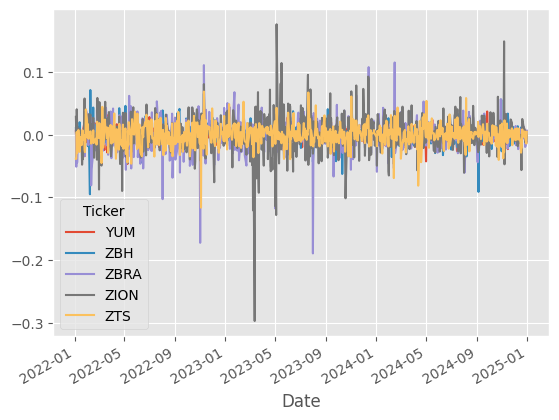

In [49]:
rets = np.log(data).diff().dropna()
rets.iloc[:,-5:].plot() # por ejemplo

In [ ]:
for i in range(rets.shape[1]):
  print(i)

In [ ]:
for e in range(0,rets.shape[1],10):
  print(e)

In [ ]:
rets.iloc[:,:4]

In [80]:

mean = []
std = []


for activo in range(2, rets.shape[1] ,1): # range(start= , stop= , step= )
  retornos = rets.iloc[:, :activo]
  pesos = np.ones(activo) / activo
  ret_cartera = retornos @ pesos
  # std_p = np.sqrt(pesos@ data.cov() @ pesos.T)
  std_p = ret_cartera.std()

  std.append(std_p)

  media = ret_cartera.mean()
  mean.append(media)

std





[0.019515756419249547,
 0.01891588401507615,
 0.01660054154042849,
 0.014048496746482076,
 0.01297921750781431,
 0.012058335011807851,
 0.011941539857368979,
 0.012257846836262905,
 0.012428264484575768,
 0.011916824775193874,
 0.01169836376750441,
 0.0120816626101949,
 0.011591759655388036,
 0.011212386940712605,
 0.011300787096504072,
 0.011069338867855006,
 0.01105630119184332,
 0.010887896374984262,
 0.010783623545432641,
 0.010685095083763349,
 0.01104597681958767,
 0.011360923012828704,
 0.011482071689378948,
 0.011326451427284496,
 0.011337081672593013,
 0.011557250260334495,
 0.011482247293782362,
 0.011808973520315711,
 0.01173078953342351,
 0.011522177994907797,
 0.011588134245082753,
 0.011506945007335534,
 0.011619589432543587,
 0.011723229988759413,
 0.011632401310222227,
 0.011624918583482309,
 0.011626398252873144,
 0.011559267854049827,
 0.011576995376651064,
 0.011731984216759018,
 0.011751144389250892,
 0.011620161508397106,
 0.011559535390570601,
 0.01163838031925022